In [2]:

# ===============================
# 1️⃣ 라이브러리 불러오기
# ===============================
import pandas as pd
import numpy as np
import re
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#======================
# 타겟
#=====================
import pandas as pd, re, unicodedata, difflib

# 0) 원본 CSV 다시 읽기(문자형 그대로)  ← 경로 정확히 넣기
CSV_PATH = r"E:\BREAST1.csv"
df_raw = pd.read_csv(CSV_PATH, dtype=str, keep_default_na=False)

# 1) 컬럼명 정규화(+후보 찾기)
orig_cols = df_raw.columns.tolist()
df_raw.columns = (df_raw.columns.astype(str)
                  .str.replace(r"\s+", " ", regex=True)
                  .str.strip())
# 'Behavior code' 유사 컬럼 자동 탐색
cands = [c for c in df_raw.columns if c.lower().replace(" ", "") in ["behaviorcode","behaviourcode"]]
if not cands:
    suggest = difflib.get_close_matches("Behavior code", df_raw.columns, n=5, cutoff=0.6)
    raise KeyError(f"'Behavior code' 컬럼을 찾지 못했습니다. 유사 후보: {suggest} / 일부 컬럼: {orig_cols[:10]}")
BEH = cands[0]  # 실제 사용할 컬럼명

# 2) 정규화 함수
def _norm(s):
    s = unicodedata.normalize("NFKC", str(s))
    s = s.replace("\u00A0"," ").replace("\u2009"," ").replace("\u200A"," ").replace("\u2002"," ")
    s = re.sub(r"\s+"," ", s.strip().lower())
    return s

# 3) 매핑 함수(숫자코드 0/1/2/3, 텍스트 'malignant'/'in situ' 모두 처리)
def to_target_from_behav(s):
    s0 = str(s)
    if re.fullmatch(r"[0-3]", s0):       # 숫자코드 케이스
        return 1 if s0 == "3" else 0
    t = _norm(s0)
    if "malignant" in t:
        return 1
    if re.search(r"in\s*[- ]?\s*situ|^cis$", t):
        return 0
    return 0

# 4) 타깃 생성 + 점검
df = df_raw.copy()
df["target_bc"] = df[BEH].map(to_target_from_behav).astype(int)

print("✅ 사용된 Behavior 컬럼명:", BEH)
print("✅ target_bc 분포:", df["target_bc"].value_counts().to_dict())

# 5) 코딩 검증(교차표)
print("\n=== 교차표(원본 vs target_bc) ===")
print(pd.crosstab(df[BEH], df["target_bc"]))


✅ 사용된 Behavior 컬럼명: Behavior code
✅ target_bc 분포: {1: 305214, 0: 3830}

=== 교차표(원본 vs target_bc) ===
target_bc         0       1
Behavior code              
In situ        3830       0
Malignant         0  305214


In [4]:
#5️⃣ 기타 컬럼 전처리
# ===============================
# Income 처리
def extract_min_income_safe(x):
    try:
        if pd.isna(x):
            return None
        if '+' in x:
            return int(x.replace('$','').replace(',','').replace('+',''))
        elif '<' in x:
            return int(x.replace('$','').replace(',','').replace('<','')) // 2
        elif '-' in x:
            parts = x.replace('$','').replace(',','').split(' - ')
            return (int(parts[0]) + int(parts[1])) // 2
        else:
            return int(x.replace('$','').replace(',',''))
    except:
        return None


df['Income_num'] = df['Income'].apply(extract_min_income_safe)


def income_group(x):
    if x is None:
        return None
    elif x < 55000:
        return 'LOW'
    elif 55000 <= x <= 89999:
        return 'MIDDLE'
    else:
        return 'HIGH'


df['Income_group'] = df['Income_num'].apply(income_group)
income_mapping = {'LOW':1, 'MIDDLE':2, 'HIGH':3, None:0}
df['Income_code'] = df['Income_group'].map(income_mapping)


# Race 그룹핑
if 'Race' in df.columns:
    df['Race_grouped'] = df['Race'].replace({
        'Unknown':'Other (Unknown/AIAN)',
        'American Indian/Alaska Native':'Other (Unknown/AIAN)'
    }).fillna('Other (Unknown/AIAN)')


# 기존 그룹핑 코드 아래에 추가
if 'Race_grouped' in df.columns:
    df['Race_grouped'] = df['Race_grouped'].astype('category').cat.codes

#


# Marital status 그룹핑
if 'Marital status' in df.columns:
    marital_map = {
        'Married (including common law)': 'Married',
        'Divorced': 'Previously Married',
        'Separated': 'Previously Married',
        'Widowed': 'Previously Married',
        'Never married': 'Single/Other',
        'Unknown': 'Single/Other',
        'Unmarried or Domestic Partner': 'Single/Other'
    }
    df['Marital_group'] = df['Marital status'].replace(marital_map).fillna('Single/Other')


# 기존 그룹핑 코드 아래에 추가
if 'Marital_group' in df.columns:
    df['Marital_group'] = df['Marital_group'].astype('category').cat.codes




# Rural-Urban 그룹핑
def group_urban_rural_keep_unknown(x):
    if pd.isna(x) or 'unknown' in str(x).lower():
        return 'Unknown'
    s = str(x)
    if 'Large Metro' in s or 'Large metro' in s or 'Large ' in s:
        return 'Large metro'
    if 'metropolitan areas of' in s or 'Small' in s or 'Medium' in s:
        return 'Small/Medium metro'
    return 'Rural'


if 'Rural-Urban' in df.columns:
    df['Rural-Urban_grouped'] = df['Rural-Urban'].apply(group_urban_rural_keep_unknown)


# 기존 그룹핑 코드 아래에 추가
if 'Rural-Urban_grouped' in df.columns:
    df['Rural-Urban_grouped'] = df['Rural-Urban_grouped'].astype('category').cat.codes




# Stage_Number 추출
def extract_stage_number(stage):
    match = re.search(r'(\d)', str(stage))
    return int(match.group(1)) if match else 0


df['Stage_Number'] = df['T/N/M Stage'].apply(extract_stage_number) if 'T/N/M Stage' in df.columns else 0


# Sequence number 기반 파생
if 'Sequence number' in df.columns:
    df['One_vs_Other'] = df['Sequence number'].apply(lambda x: 1 if str(x) == "One primary only" else 0)
    def first_vs_later_safe(value):
        if value == 'One primary only':
            return -1
        elif value == '1st of 2 or more primaries':
            return 1
        else:
            return 0
    df['First_vs_Later'] = df['Sequence number'].apply(first_vs_later_safe)
else:
    df['One_vs_Other'] = 0
    df['First_vs_Later'] = 0


# cancer treatment delay 처리
df['cancer treatment delay'] = df['cancer treatment delay'].replace('Unable to calculate','Unknown')
df['cancer treatment delay_num'] = pd.to_numeric(df['cancer treatment delay'], errors='coerce')
def categorize_delay(x):
    if pd.isna(x):
        return 3
    elif 0 <= x <= 30:
        return 0
    elif 31 <= x <= 60:
        return 1
    elif x >= 61:
        return 2
    else:
        return 3
df['cancer_delay_label'] = df['cancer treatment delay_num'].apply(categorize_delay)
df.loc[df['cancer treatment delay']=='Unknown','cancer_delay_label'] = 3

#Surgery prim
df['Surgery Prim Site_binary'] = df['Surgery Prim Site'].apply(lambda x: 0 if x == 0 else 1)


# Surgery_Reg_Group
def surgery_other_group(value):
    if value in ['0', 'None; diagnosed at autopsy', 'Unknown; death certificate only']:
        return 0
    elif value in [
        'Non-primary surgical procedure performed',
        'Non-primary surgical procedure to other regional sites',
        'Non-primary surgical procedure to distant site',
        'Non-primary surgical procedure to distant lymph node(s)',
        'Any combo of sur proc to oth rg, dis lym nd, and/or dis site'
    ]:
        return 1
    else:
        return None

df['Surgery_Reg_Group'] = df['Surgery Oth Reg/Dis'].apply(surgery_other_group)
df = df[df['Surgery_Reg_Group'].notna()]


# Radiation_binary
df['Radiation_binary'] = df['Radiation'].apply(lambda x: 0 if x in ["None/Unknown", "Refused (1988+)", "Recommended, unknown if administered"] else 1)

# Chemo_Binary
def chemo_binary(value):
    if value == 'No/Unknown':
        return 0
    elif value == 'Yes':
        return 1
    else:
        return None


df['Chemo_Binary'] = df['Chemotherapy'].apply(chemo_binary)

df['Survival months'] = pd.to_numeric(df['Survival months'], errors='coerce')

# 주요 binary 변수 변환
binary_cols = ['Sex','ER','PR','HER2','Mets at bone','Mets at brain','Mets at liver','Mets at lung']
for col in binary_cols:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: 1 if any(k in str(x).lower() for k in ['yes','positive','female','malignant','1']) else 0)
    else:
        df[col] = 0


# Age ordinal
if 'Age' in df.columns:
    try:
        age_cats = sorted(df['Age'].dropna().unique())
        age_map = {cat:i for i,cat in enumerate(age_cats)}
        df['Age_ord'] = df['Age'].map(age_map).fillna(0).astype(int)
    except:
        df['Age_ord'] = 0
else:
    df['Age_ord'] = 0


print(df.columns)


Index(['Sex', 'Age', 'Race', 'Marital status', 'ER', 'HER2', 'PR',
       'T/N/M Stage', 'Behavior code', 'Sequence number', 'Chemotherapy',
       'Mets all', 'Mets at bone', 'Mets at brain', 'Mets at liver',
       'Mets at lung', 'Radiation', 'Surgery Oth Reg/Dis', 'Surgery Prim Site',
       'Rural-Urban', 'cancer treatment delay', 'Income', 'Survival months',
       'Cancer Site', 'target_bc', 'Income_num', 'Income_group', 'Income_code',
       'Race_grouped', 'Marital_group', 'Rural-Urban_grouped', 'Stage_Number',
       'One_vs_Other', 'First_vs_Later', 'cancer treatment delay_num',
       'cancer_delay_label', 'Surgery Prim Site_binary', 'Surgery_Reg_Group',
       'Radiation_binary', 'Chemo_Binary', 'Age_ord'],
      dtype='object')


In [5]:
# ===============================
# 1️⃣ 중복/불필요 컬럼 제거 기준 설정
# ===============================
drop_cols = [
    # 원본 + 중복 컬럼
    'Age', 'Behavior code', 'Cancer Site', 'Mets all',
    'cancer treatment delay','cancer treatment delay_num',
    'Surgery Prim Site', 'Surgery Oth Reg/Dis', 'Radiation',
    'Chemotherapy','Behavior_is_insitu','Marital status','Income','target_bc'
    # 전처리 중복 컬럼
    'Income'
    # 원본 컬럼 제거(전처리 컬럼 남기기)
    'Marital status', 'Race', 'Rural-Urban', 'T/N/M Stage', 'Sequence number','Income_num', 'Income_group', 'labeling'
]

In [6]:
# ===============================
# 2️⃣ X/y 분리
# ===============================
X = df.drop(columns=[c for c in drop_cols if c in df.columns])
y = df['target_bc']
# 3️⃣ 범주형 -> 숫자 변환
# ===============================
for col in X.select_dtypes('category').columns:
    X[col] = X[col].cat.codes


In [7]:
# ===============================
# 4️⃣ 결측값 0으로 채우기
# ===============================
X = X.fillna(0)


# ===============================
# 5️⃣ 결과 확인
# ===============================
print("X shape:", X.shape)
print("Columns:", X.columns.tolist())
print("y unique values:", np.unique(y))

X shape: (309044, 23)
Columns: ['Sex', 'ER', 'HER2', 'PR', 'Mets at bone', 'Mets at brain', 'Mets at liver', 'Mets at lung', 'Survival months', 'target_bc', 'Income_code', 'Race_grouped', 'Marital_group', 'Rural-Urban_grouped', 'Stage_Number', 'One_vs_Other', 'First_vs_Later', 'cancer_delay_label', 'Surgery Prim Site_binary', 'Surgery_Reg_Group', 'Radiation_binary', 'Chemo_Binary', 'Age_ord']
y unique values: [0 1]


In [8]:
print(X.dtypes)

Sex                         int64
ER                          int64
HER2                        int64
PR                          int64
Mets at bone                int64
Mets at brain               int64
Mets at liver               int64
Mets at lung                int64
Survival months             int64
target_bc                   int32
Income_code                 int64
Race_grouped                 int8
Marital_group                int8
Rural-Urban_grouped          int8
Stage_Number                int64
One_vs_Other                int64
First_vs_Later              int64
cancer_delay_label          int64
Surgery Prim Site_binary    int64
Surgery_Reg_Group           int64
Radiation_binary            int64
Chemo_Binary                int64
Age_ord                     int32
dtype: object


NameError: name 'Marital_group' is not defined

=== Target 분포(개수) ===
target_bc
1    305214
0      3830
Name: count, dtype: int64

=== Target 분포(비율 %) ===
target_bc
1    98.76
0     1.24
Name: proportion, dtype: float64


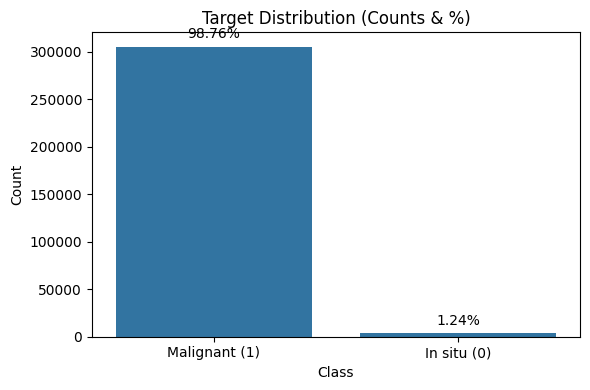

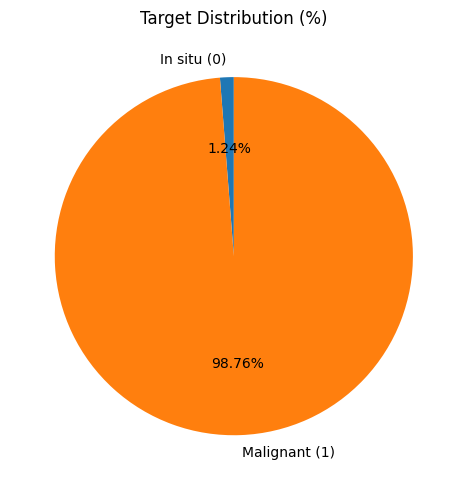


=== 교차표(Behavior code vs target_bc) ===
target_bc         0       1
Behavior code              
In situ        3830       0
Malignant         0  305214


In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1) 수치 확인 (개수 / 비율)
print("=== Target 분포(개수) ===")
print(df['target_bc'].value_counts())

print("\n=== Target 분포(비율 %) ===")
print((df['target_bc'].value_counts(normalize=True)*100).round(2))

# 2) 라벨 붙여서 막대그래프 (개수 + % 주석)
label_map = {0: 'In situ (0)', 1: 'Malignant (1)'}
tmp = (df['target_bc']
       .map(label_map)
       .value_counts()
       .rename_axis('class')
       .reset_index(name='count'))
tmp['ratio'] = tmp['count'] / tmp['count'].sum()

plt.figure(figsize=(6,4))
ax = sns.barplot(x='class', y='count', data=tmp)
ax.set_title('Target Distribution (Counts & %)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')

# 막대 위에 % 표기
for p, r in zip(ax.patches, tmp['ratio']):
    ax.annotate(f"{r*100:.2f}%",
                (p.get_x()+p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10, xytext=(0,4), textcoords='offset points')
plt.tight_layout()
plt.show()

# 3) 파이차트 (비율)
counts = df['target_bc'].value_counts().sort_index()
plt.figure(figsize=(5,5))
plt.pie(counts,
        labels=[label_map[i] for i in counts.index],
        autopct="%.2f%%", startangle=90)
plt.title("Target Distribution (%)")
plt.tight_layout()
plt.show()

# (선택) 원본 Behavior code와의 일관성 체크
print("\n=== 교차표(Behavior code vs target_bc) ===")
print(pd.crosstab(df['Behavior code'], df['target_bc']))


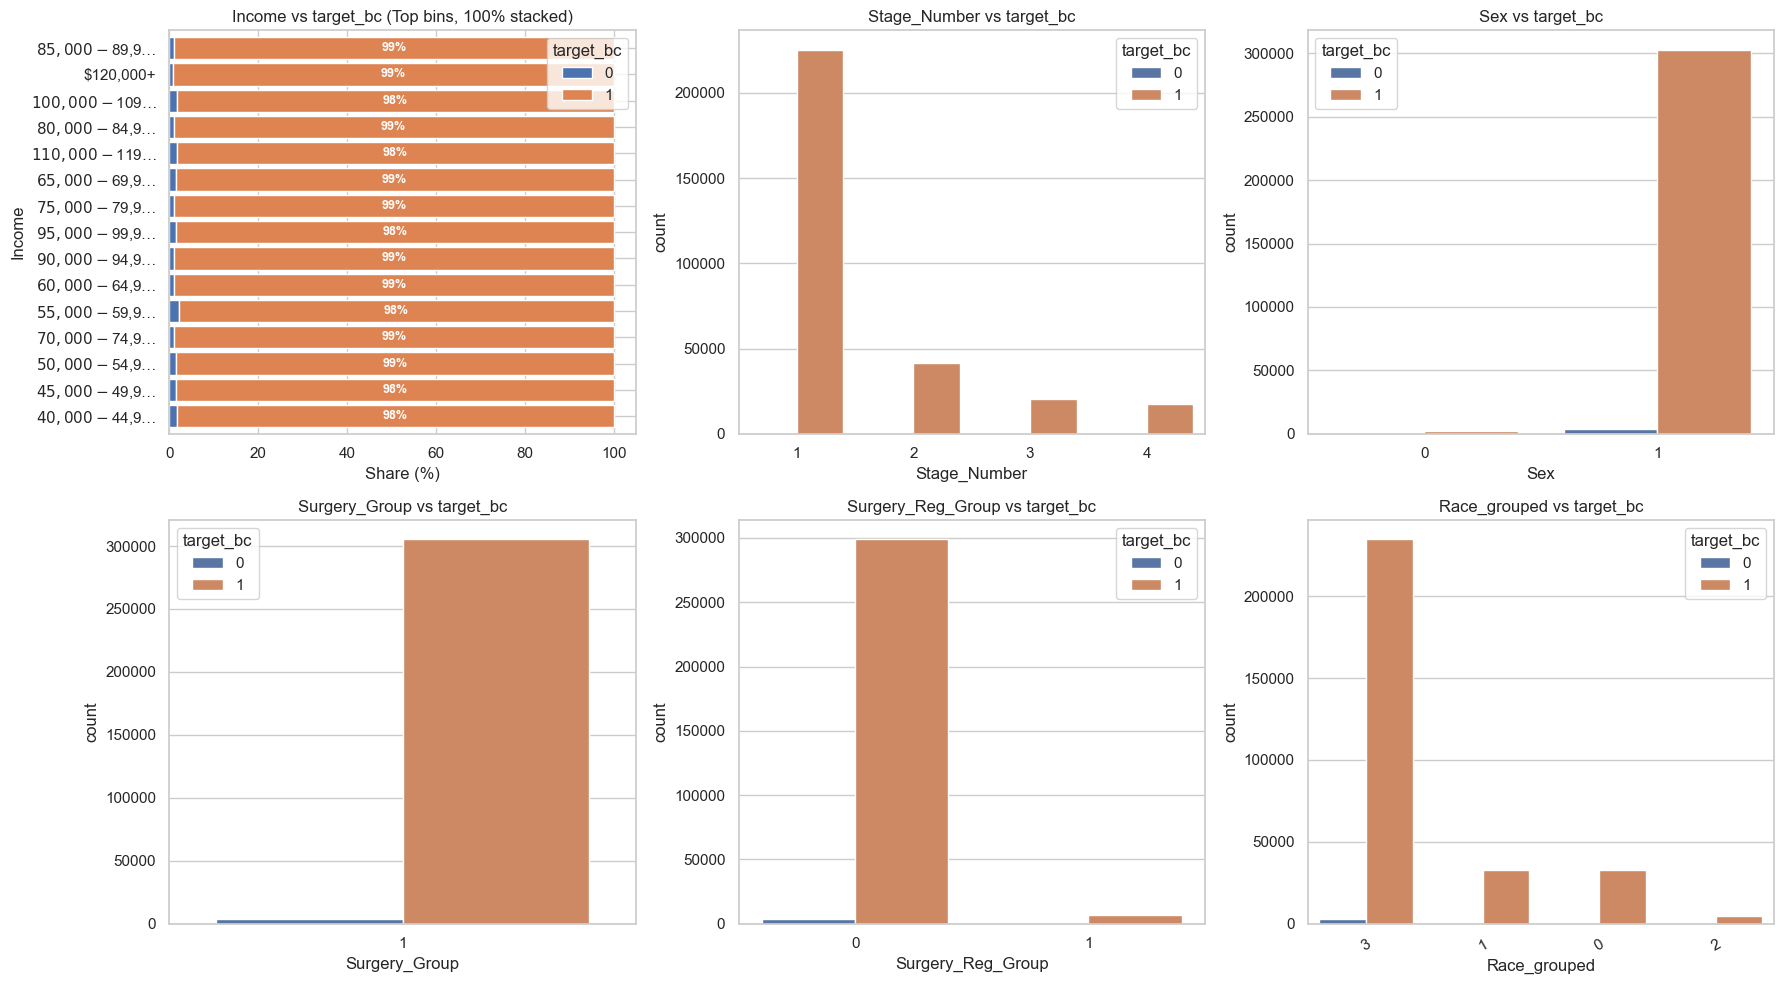

In [10]:
import re, numpy as np, pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ===== 0) 보조 함수 =====
def lower_bound(x: str):
    """Income 구간의 하한값을 정수로 추출해서 정렬 기준으로 사용."""
    s = str(x)
    m = re.search(r"(\d{1,3}(?:,\d{3})*)", s)
    return int(m.group(1).replace(",", "")) if m else np.inf

def short_label(s: str, maxlen=16):
    s = str(s).strip()
    s = s.replace("Unknown/missing/no match/not 1980-2023", "Unknown")
    return s if len(s) <= maxlen else s[:maxlen-1] + "…"

# ===== 1) Income 100% 스택 비율용 집계 =====
TOP_N = 15
ct = pd.crosstab(df['Income'], df['target_bc'])

# Income 구간을 자연스러운 숫자 순서로 정렬 → 상위 TOP_N만
order_income = sorted(ct.index, key=lower_bound)
ct = ct.reindex(order_income)
ct = ct.loc[ct.sum(1).sort_values(ascending=False).index]  # 총합 기준 정렬
ct_top = ct.head(TOP_N).iloc[::-1].copy()                   # 위에서 아래로 보이게 반전
ct_top.index = [short_label(i) for i in ct_top.index]

row_sum = ct_top.sum(axis=1).replace(0, np.nan)
ct_pct = (ct_top.div(row_sum, axis=0) * 100)

# ===== 2) Figure(2x3) 생성 =====
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
ax = axes.ravel()

# (1) Income – 100% stacked horizontal
ct_pct.plot(kind='barh', stacked=True, ax=ax[0], width=0.85, legend=True)
ax[0].set_title("Income vs target_bc (Top bins, 100% stacked)")
ax[0].set_xlabel("Share (%)")
ax[0].set_ylabel("Income")
# 막대 안 % 라벨 (5% 이상만)
for p in ax[0].patches:
    w = p.get_width()
    if w >= 5:
        ax[0].text(p.get_x() + w/2, p.get_y() + p.get_height()/2,
                   f"{w:.0f}%", ha="center", va="center",
                   color="white", fontsize=9, weight="bold")

# (2) Stage_Number
sns.countplot(x='Stage_Number', hue='target_bc', data=df, order=[1,2,3,4], ax=ax[1])
ax[1].set_title('Stage_Number vs target_bc')
ax[1].set_xlabel('Stage_Number'); ax[1].set_ylabel('count')

# (3) Sex
sns.countplot(x='Sex', hue='target_bc', data=df, ax=ax[2])
ax[2].set_title('Sex vs target_bc'); ax[2].set_xlabel('Sex')

# (4) Surgery_Group
sns.countplot(x='Surgery Prim Site_binary', hue='target_bc', data=df, ax=ax[3])
ax[3].set_title('Surgery_Group vs target_bc'); ax[3].set_xlabel('Surgery_Group')

# (5) Surgery_Reg_Group
sns.countplot(x='Surgery_Reg_Group', hue='target_bc', data=df, ax=ax[4])
ax[4].set_title('Surgery_Reg_Group vs target_bc'); ax[4].set_xlabel('Surgery_Reg_Group')

# (6) Race_grouped (빈도순 정렬 + 라벨 회전)
race_order = df['Race_grouped'].value_counts().index
sns.countplot(x='Race_grouped', hue='target_bc', data=df, order=race_order, ax=ax[5])
ax[5].set_title('Race_grouped vs target_bc'); ax[5].set_xlabel('Race_grouped')
ax[5].tick_params(axis='x', rotation=30)

# 공통: 범례 자리 정리
for a in ax:
    if a.get_legend():
        a.legend(title='target_bc', loc='best')

plt.tight_layout()
plt.show()


In [11]:
num_features = [
    'Sex','ER','PR','HER2',
    'Mets at bone','Mets at brain','Mets at liver','Mets at lung',
    'Survival months','Income_code',
    'Race_grouped','Marital_group','Rural-Urban_grouped',
    'Stage_Number','One_vs_Other','First_vs_Later',
    'cancer_delay_label','Age_ord',
    'Surgery Prim Site_binary','Surgery_Reg_Group',
    'Radiation_binary','Chemo_Binary'
]

# 실제 존재하는 것만 추리기
num_features = [c for c in num_features if c in df.columns]

X = df[num_features].copy()
y = df['target_bc'].astype(int).copy()

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.dtypes)  # object 타입이 없어야 정상


Sex                         int64
ER                          int64
PR                          int64
HER2                        int64
Mets at bone                int64
Mets at brain               int64
Mets at liver               int64
Mets at lung                int64
Survival months             int64
Income_code                 int64
Race_grouped                 int8
Marital_group                int8
Rural-Urban_grouped          int8
Stage_Number                int64
One_vs_Other                int64
First_vs_Later              int64
cancer_delay_label          int64
Age_ord                     int32
Surgery Prim Site_binary    int64
Surgery_Reg_Group           int64
Radiation_binary            int64
Chemo_Binary                int64
dtype: object


In [28]:
from imblearn.over_sampling import RandomOverSampler

# 오버샘플링 객체 생성
ros = RandomOverSampler(random_state=42)

# 훈련 데이터(X_train, y_train)에 대해 오버샘플링 적용
X_resampled, y_resampled = ros.fit_resample(X_train, y_train)

print("원본 데이터 클래스 분포:")
print(y_train.value_counts())
print("\n오버샘플링 후 클래스 분포:")
print(y_resampled.value_counts())

원본 데이터 클래스 분포:
target_bc
1    244171
0      3064
Name: count, dtype: int64

오버샘플링 후 클래스 분포:
target_bc
1    244171
0    244171
Name: count, dtype: int64


In [ ]:

# 데이터 분리 & 평가
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score, f1_score

# 분류 모델들
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# 부스팅 계열
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
# === 1. 비교 모델 세트 ===
models = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),  
    #"KNN": KNeighborsClassifier(n_neighbors=5),      
    #"LinearSVM": SVC(kernel="linear", probability=True, random_state=42),
    "GNB": GaussianNB(),
    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="logloss"
    )
}
# --- 2) 학습 & 평가 유틸 ---
def eval_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # 확률 점수 얻기 (predict_proba가 없으면 decision_function을 확률처럼 정규화)
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, "decision_function"):
        df = model.decision_function(X_te)
        # min-max로 [0,1] 스케일 (순위 기반 ROC-AUC에는 큰 문제 없음)
        df_min, df_max = df.min(), df.max()
        y_score = (df - df_min) / (df_max - df_min + 1e-9)
    else:
        # 확률이 전혀 없으면 예측(0/1)로 대체(ROC-AUC는 덜 의미 있음)
        y_score = y_pred

    rep = classification_report(y_te, y_pred, output_dict=True, zero_division=0)
    auc = roc_auc_score(y_te, y_score)
    tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()

    row = {
        "Model": name,
        "Accuracy": rep["accuracy"],
        "Precision(1)": rep["1"]["precision"],
        "Recall(1)": rep["1"]["recall"],
        "F1(1)": rep["1"]["f1-score"],
        "ROC-AUC": auc,
        "TP": tp, "FP": fp, "TN": tn, "FN": fn
    }
    return row, rep

# --- 3) 전체 모델 실행 ---
rows = []
reports = {}
for name, m in models.items():
    try:
        # 학습은 X_train, y_train
        row, rep = eval_model(name, m, X_train, y_train, X_test, y_test)
        rows.append(row)
        reports[name] = rep
    except Exception as e:
        print(f"[WARN] {name} 실행 중 오류 → 스킵: {e}")

df_results = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False)
print("=== Model comparison (no oversampling) ===")
print(df_results.to_string(index=False))

best_model_name = df_results.iloc[0]["Model"]
print(f"\nBest model (no oversampling): {best_model_name}")

=== Model comparison (with RandomOverSampler) ===
           Model  Accuracy  Precision(1)  Recall(1)    F1(1)  ROC-AUC    TP  FP  TN  FN
GradientBoosting  0.999709      1.000000   0.999705 0.999853 0.999903 61025   0 766  18
    RandomForest  0.999596      0.999984   0.999607 0.999795 0.999892 61019   1 765  24
         XGBoost  0.999596      0.999984   0.999607 0.999795 0.999873 61019   1 765  24
             GNB  0.999709      1.000000   0.999705 0.999853 0.999866 61025   0 766  18
    DecisionTree  0.999272      0.999607   0.999656 0.999631 0.984210 61022  24 742  21

Best model after oversampling: GradientBoosting


In [16]:
pip install -U xgboost

Note: you may need to restart the kernel to use updated packages.


xgboost version: 3.0.4
ROC AUC: 0.9998898392431411
              precision    recall  f1-score   support

           0     0.9696    1.0000    0.9846       766
           1     1.0000    0.9996    0.9998     61043

    accuracy                         0.9996     61809
   macro avg     0.9848    0.9998    0.9922     61809
weighted avg     0.9996    0.9996    0.9996     61809



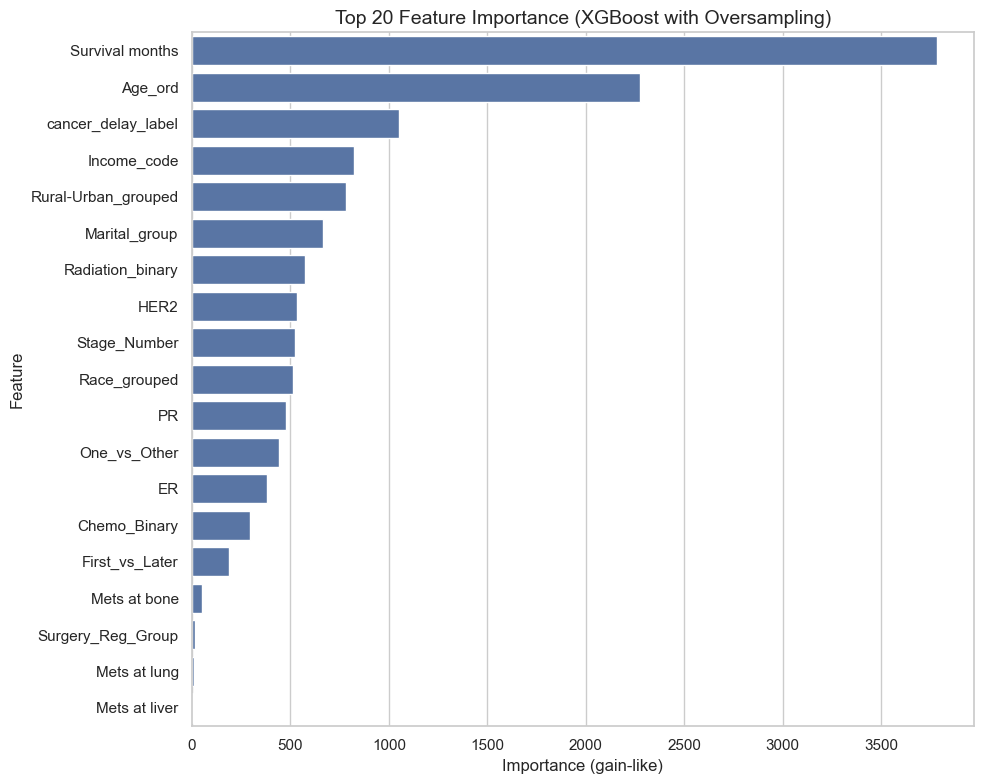

In [32]:
# 0) 버전 확인(문제 계속이면 이 숫자도 같이 알려줘요)
import xgboost as xgb
print("xgboost version:", xgb.__version__)

from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1) 입력 안전 점검: 모두 숫자형 + NaN/Inf 제거
def _to_numeric_df(df_):
    df_ = df_.copy()
    for c in df_.columns:
        if not np.issubdtype(df_[c].dtype, np.number):
            df_[c] = pd.to_numeric(df_[c], errors="coerce")
    df_.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df_.fillna(0)

X_train_safe = _to_numeric_df(X_train)
X_test_safe  = _to_numeric_df(X_test)
y_train_safe = y_train.values if hasattr(y_train, "values") else y_train
y_test_safe  = y_test.values  if hasattr(y_test, "values")  else y_test

# 2) 모델 정의(최소 인자: 구버전도 수용)
xgbm = XGBClassifier(
    n_estimators=600,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    n_jobs=-1,
    random_state=42
    # ※ early_stopping, callbacks 등은 일부 구버전에서 미지원 → 사용 안 함
)

# 3) 학습 (훈련데이터: 오버샘플링된 것 사용)
xgbm.fit(X_resampled, y_resampled)

# 4) 예측 (테스트 데이터는 그대로 사용)
y_pred  = xgbm.predict(X_test_safe)
y_proba = xgbm.predict_proba(X_test_safe)[:, 1]

print("ROC AUC:", roc_auc_score(y_test_safe, y_proba))
print(classification_report(y_test_safe, y_pred, digits=4))

# 5) Feature Importance (구버전 호환: f0,f1… → 실제 컬럼명 매핑)
booster = xgbm.get_booster()
fs = booster.get_fscore()  # dict: {'f0':score, 'f1':score, ...}

# f0,f1… → 실제 피처명으로 매핑
fmap = {f"f{idx}": col for idx, col in enumerate(X_resampled.columns)}
imp_rows = [(fmap.get(k, k), v) for k, v in fs.items()]
feat_importance = (pd.DataFrame(imp_rows, columns=["feature", "importance"])
                   .sort_values("importance", ascending=False))

# 시각화
plt.figure(figsize=(10, 8))
sns.barplot(x="importance", y="feature", data=feat_importance.head(20))
plt.title("Top 20 Feature Importance (XGBoost with Oversampling)", fontsize=14)
plt.xlabel("Importance (gain-like)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


ROC AUC: 0.999896137504235
              precision    recall  f1-score   support

           0     0.9696    0.9987    0.9839       766
           1     1.0000    0.9996    0.9998     61043

    accuracy                         0.9996     61809
   macro avg     0.9848    0.9992    0.9919     61809
weighted avg     0.9996    0.9996    0.9996     61809



C:\Users\user\AppData\Local\Temp\ipykernel_1536\2734923878.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_importance.head(20), palette='crest')


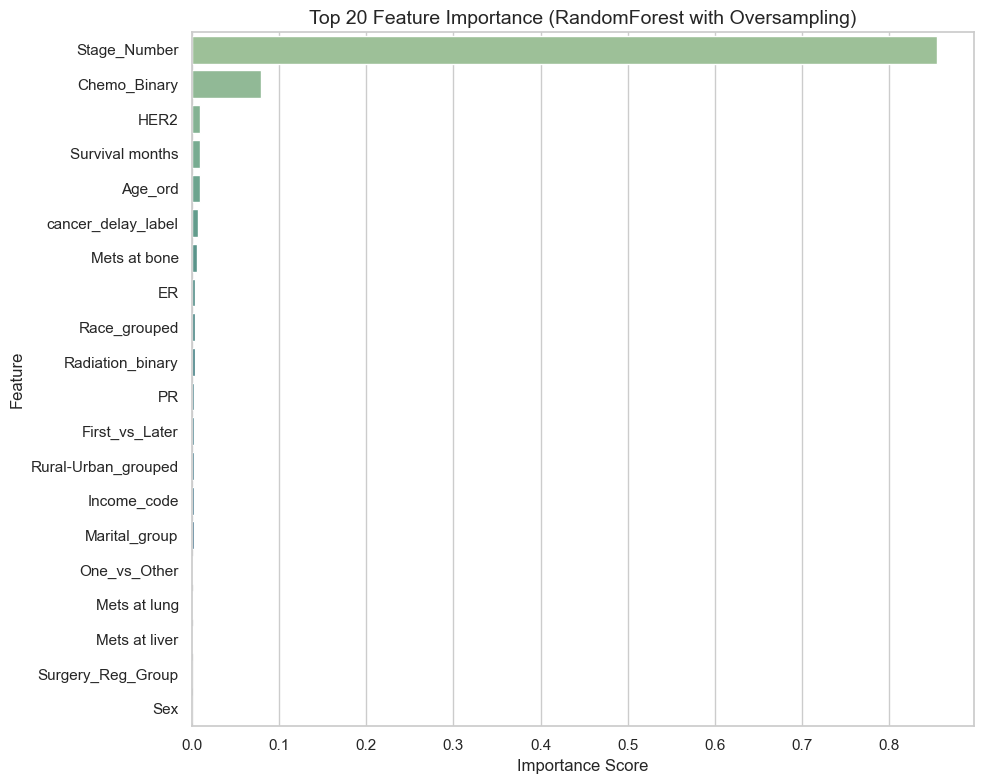

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)

# 학습: 오버샘플링된 데이터 사용
rf.fit(X_resampled, y_resampled)

# 평가: 원래 테스트셋으로 진행
y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=4))

# Feature Importance 시각화
feat_importance = pd.DataFrame({
    'feature': X_resampled.columns,   # 학습에 사용된 컬럼 기준
    'importance': rf.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_importance.head(20), palette='crest')
plt.title("Top 20 Feature Importance (RandomForest with Oversampling)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



ROC AUC: 0.9999164865549341
              precision    recall  f1-score   support

           0     0.9708    1.0000    0.9852       766
           1     1.0000    0.9996    0.9998     61043

    accuracy                         0.9996     61809
   macro avg     0.9854    0.9998    0.9925     61809
weighted avg     0.9996    0.9996    0.9996     61809



C:\Users\user\AppData\Local\Temp\ipykernel_1536\2237797017.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=feat_importance.head(20), palette='mako')


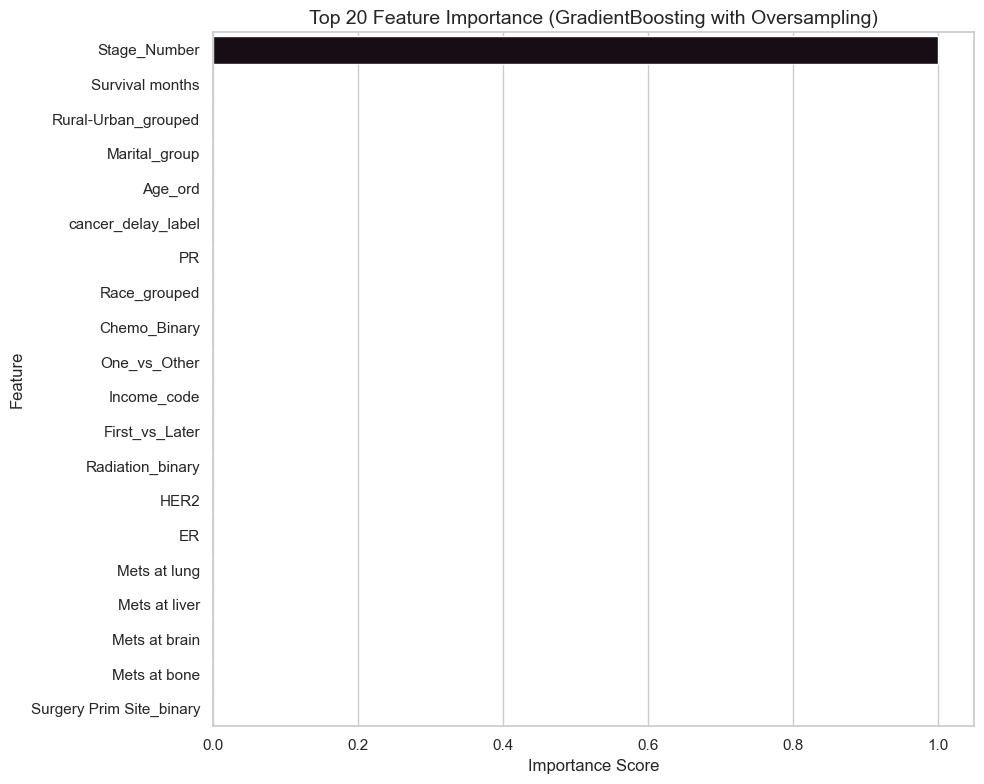

In [34]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 모델 정의 & 학습 (훈련 데이터 = 오버샘플링된 데이터)
# -------------------------
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gb.fit(X_resampled, y_resampled)

# -------------------------
# 예측 (테스트 데이터 = 원본)
# -------------------------
y_pred = gb.predict(X_test)
y_proba = gb.predict_proba(X_test)[:, 1]

# -------------------------
# 평가
# -------------------------
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=4))

# -------------------------
# Feature Importance 시각화
# -------------------------
feat_importance = pd.DataFrame({
    'feature': X_resampled.columns,  # 학습에 사용된 컬럼 기준
    'importance': gb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feat_importance.head(20), palette='mako')
plt.title("Top 20 Feature Importance (GradientBoosting with Oversampling)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


ROC AUC: 0.7937265705221962
              precision    recall  f1-score   support

           0     0.0270    0.7559    0.0522       766
           1     0.9954    0.6584    0.7926     61043

    accuracy                         0.6596     61809
   macro avg     0.5112    0.7071    0.4224     61809
weighted avg     0.9834    0.6596    0.7834     61809



C:\Users\user\AppData\Local\Temp\ipykernel_1536\3492237980.py:72: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature',


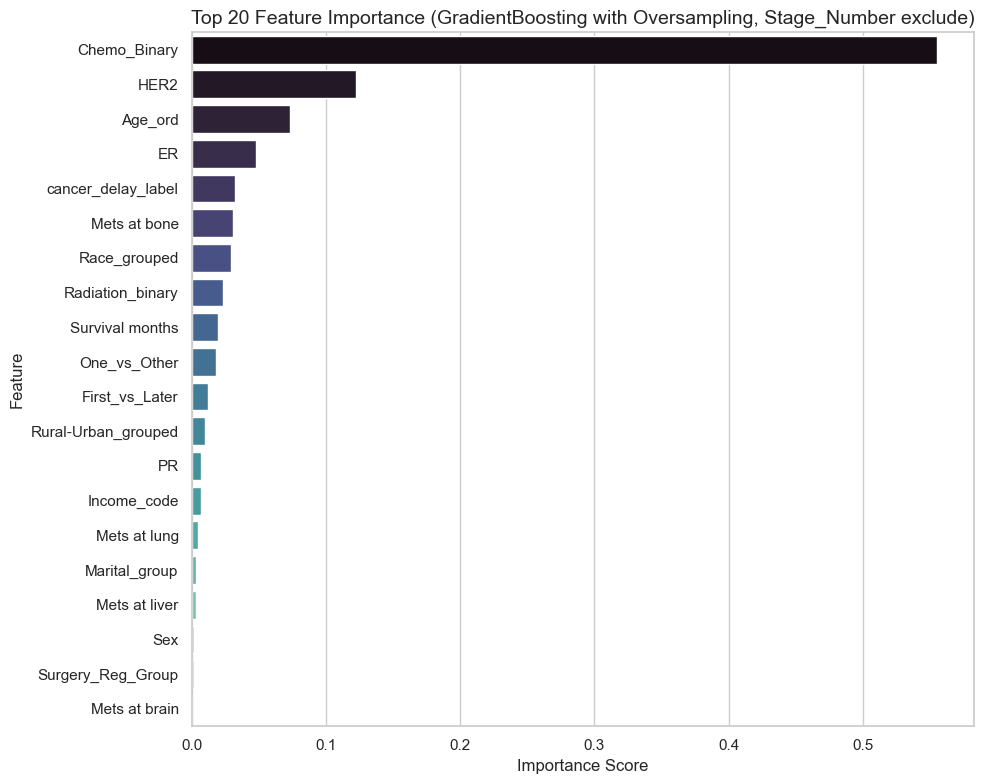

In [36]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# 1) 피처/타깃 준비 (동일)
# -------------------------
num_features = [
    'Sex','ER','PR','HER2',
    'Mets at bone','Mets at brain','Mets at liver','Mets at lung',
    'Survival months','Income_code',
    'Race_grouped','Marital_group','Rural-Urban_grouped',
    'Stage_Number','One_vs_Other','First_vs_Later','cancer_delay_label','Age_ord',
    'Surgery Prim Site_binary','Surgery_Reg_Group','Radiation_binary','Chemo_Binary'
]
num_features = [c for c in num_features if c in df.columns]

X = df[num_features].copy()
y = df['target_bc'].astype(int).copy()

# 숫자 강제 변환 + 결측 0 처리
X = X.apply(pd.to_numeric, errors='coerce').fillna(0)

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Stage_Number 제외
X_train_reduced = X_train.drop(columns=['Stage_Number'], errors='ignore')
X_test_reduced  = X_test.drop(columns=['Stage_Number'], errors='ignore')

# -------------------------
# 2) 오버샘플링 (훈련 데이터만 적용)
# -------------------------
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_reduced, y_train)

# -------------------------
# 3) 모델 정의 & 학습 (오버샘플링 데이터 사용)
# -------------------------
gb = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,       # 개별 트리 깊이
    random_state=42
)
gb.fit(X_resampled, y_resampled)

# -------------------------
# 4) 예측 & 평가 (테스트셋은 원본 그대로)
# -------------------------
y_pred  = gb.predict(X_test_reduced)
y_proba = gb.predict_proba(X_test_reduced)[:, 1]

print("ROC AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=4))

# -------------------------
# 5) Feature Importance 시각화
# -------------------------
feat_importance_reduced = pd.DataFrame({
    'feature': X_resampled.columns,
    'importance': gb.feature_importances_
}).sort_values(by='importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature',
            data=feat_importance_reduced.head(20), palette='mako')
plt.title("Top 20 Feature Importance (GradientBoosting with Oversampling, Stage_Number exclude)", fontsize=14)
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


In [22]:
! pip install optuna

In [43]:
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
import numpy as np
import pandas as pd

# 1) y를 숫자형으로 강제 (혼재 방지)
y_train_clean = pd.Series(y_train).astype(int)
print("원본 학습 분포:", Counter(y_train_clean))

# 2) Stage_Number 제외한 학습 피처 사용 중이면, 같은 걸로 resample
X_train_use = X_train_reduced  # 또는 사용 중인 학습용 X

# 3) 오버샘플링 (기본: minority를 majority에 맞춤 → 개수 같아져야 함)
ros = RandomOverSampler(sampling_strategy='auto', random_state=42)
X_resampled, y_resampled = ros.fit_resample(X_train_use, y_train_clean)

print("오버샘플링 후 분포:", Counter(y_resampled))

# 4) 정말 같은지 강제 확인
counts = Counter(y_resampled)
assert len(counts) == 2, f"이상한 레이블 탐지: {counts}"
assert counts[0] == counts[1], f"클래스 불균형 유지됨: {counts}"

# 5) 이후 모델 학습은 반드시 X_resampled, y_resampled 사용
# gb.fit(X_resampled, y_resampled)  # 예시


원본 학습 분포: Counter({1: 244171, 0: 3064})
오버샘플링 후 분포: Counter({1: 244171, 0: 244171})


In [44]:
X_resampled, X_test, y_resampled, y_test = train_test_split(X, y,
                                                    test_size = 0.2,
                                                    stratify = y, # 클래스 분포 비율 맞추기
                                                    random_state = 42)
print("train 데이터: ", X_resampled.shape)
print("test 데이터: ", X_test.shape)




train 데이터:  (247235, 22)
test 데이터:  (61809, 22)


In [160]:
#누수 제거
leak_cols = [
    'Survival months',
    'Mets at bone','Mets at brain','Mets at liver','Mets at lung',
    'Surgery Prim Site_binary','Surgery_Reg_Group',
    'Radiation_binary','Chemo_Binary','Stage_Number'
]
use_cols = [c for c in X_train.columns if c not in leak_cols]

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, classification_report

pipe = Pipeline([
    ("ros", RandomOverSampler(random_state=42)),
    ("gb",  GradientBoostingClassifier(random_state=42))
])

pipe.fit(X_train[use_cols], y_train)
y_pred  = pipe.predict(X_test[use_cols])
y_proba = pipe.predict_proba(X_test[use_cols])[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=4))


ROC-AUC: 0.6335067212176632
              precision    recall  f1-score   support

           0     0.0192    0.5300    0.0371       766
           1     0.9912    0.6610    0.7931     61043

    accuracy                         0.6594     61809
   macro avg     0.5052    0.5955    0.4151     61809
weighted avg     0.9791    0.6594    0.7837     61809



In [ ]:
import optuna, numpy as np, pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, average_precision_score, classification_report, confusion_matrix

# --- 임계값 선택 함수(넘파이 변환) ---
from sklearn.metrics import roc_curve
def choose_threshold(y_true, y_score, min_specificity=0.20, min_precision=0.90, maximize="gmean"):
    Y = np.asarray(y_true, dtype=int).reshape(-1)
    S = np.asarray(y_score, dtype=float).reshape(-1)
    fpr, tpr, thr = roc_curve(Y, S)
    S2  = S.reshape(-1, 1)          # (n,1)
    THR = np.asarray(thr).reshape(1, -1)  # (1,t)

    P = (Y == 1).sum(); N = (Y == 0).sum()
    preds = (S2 >= THR)              # (n,t)
    TP = (preds & (Y[:,None]==1)).sum(axis=0)
    FP = (preds & (Y[:,None]==0)).sum(axis=0)
    FN = P - TP; TN = N - FP

    precision   = TP / (TP + FP + 1e-12)
    recall      = TP / (TP + FN + 1e-12)
    specificity = TN / (TN + FP + 1e-12)

    mask = (specificity >= min_specificity) & (precision >= min_precision)
    if not np.any(mask):
        score = np.sqrt(recall * specificity)
        best_idx = int(np.nanargmax(score))
        return float(thr[best_idx])

    if maximize == "balacc":
        score = 0.5 * (recall + specificity)
    elif maximize == "macro_f1":
        f1_pos = 2*TP / (2*TP + FP + FN + 1e-12)
        f1_neg = 2*TN / (2*TN + FN + FP + 1e-12)
        score = 0.5*(f1_pos + f1_neg)
    else:  # gmean
        score = np.sqrt(recall * specificity)

    best_idx = int(np.nanargmax(np.where(mask, score, -np.inf)))
    return float(thr[best_idx])

# --- CV 설정 ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def objective_gb_bal(trial):
    # y를 Series로 보장(iloc 사용)
    y_ser = pd.Series(y_train).astype(int)

    gb = GradientBoostingClassifier(
        n_estimators      = trial.suggest_int("n_estimators", 100, 800),
        learning_rate     = trial.suggest_float("learning_rate", 1e-3, 0.2, log=True),
        max_depth         = trial.suggest_int("max_depth", 2, 6),
        subsample         = trial.suggest_float("subsample", 0.6, 1.0),
        max_features      = trial.suggest_float("max_features", 0.5, 1.0),
        min_samples_split = trial.suggest_int("min_samples_split", 2, 20),
        min_samples_leaf  = trial.suggest_int("min_samples_leaf", 1, 20),
        min_impurity_decrease = trial.suggest_float("min_impurity_decrease", 1e-12, 1e-2, log=True),
        validation_fraction = 0.1,
        n_iter_no_change   = trial.suggest_int("n_iter_no_change", 20, 80),
        tol                = trial.suggest_float("tol", 1e-5, 1e-3, log=True),
        random_state       = 42
    )
    sampling = trial.suggest_float("sampling_strategy", 0.2, 1.0)

    pipe = Pipeline([
        ("ros", RandomOverSampler(random_state=42, sampling_strategy=sampling)),
        ("gb",  gb),
    ])

    scores = []
    for tr_idx, va_idx in cv.split(X_train, y_ser):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va= y_ser.iloc[tr_idx],  y_ser.iloc[va_idx]

        pipe.fit(X_tr, y_tr)  # 훈련 파트에만 ROS 적용
        proba = pipe.predict_proba(X_va)[:, 1]

        thr = choose_threshold(y_true=np.asarray(y_va),
                               y_score=np.asarray(proba),
                               min_specificity=0.20,
                               min_precision=0.90,
                               maximize="gmean")
        y_pred = (proba >= thr).astype(int)
        scores.append(balanced_accuracy_score(y_va, y_pred))

    return float(np.mean(scores))  # ✅ 루프 바깥에서 반환

In [156]:
X_train_use, X_test_use = X_train, X_test
# 완전 동일 행이 얼마나 겹치는지 대략 확인
overlap = pd.merge(
    X_train_use.assign(_=1).head(10000),  # 큰 데이터면 일부 샘플
    X_test_use.assign(_=1),
    on=use_cols
).shape[0]
print("Train/Test 완전중복 행(샘플링 기준):", overlap)



Train/Test 완전중복 행(샘플링 기준): 419585


In [157]:
from sklearn.metrics import roc_auc_score
y_shuf = y_train.sample(frac=1, random_state=0).reset_index(drop=True)

# 피처/타깃 인덱스 정렬
X_trn = X_train_use.reset_index(drop=True)
final_pipe.fit(X_trn, y_shuf)

proba_shuf = final_pipe.predict_proba(X_test_use)[:,1]
print("AUC with shuffled labels:", roc_auc_score(y_test, proba_shuf))
# 정상이라면 ~0.5 근처여야 합니다. 높게 나오면 강한 누수.


AUC with shuffled labels: 0.46388609168155187


In [84]:
# --- 최적화 실행 ---
study = optuna.create_study(direction="maximize")
study.optimize(objective_gb_bal, n_trials=20, show_progress_bar=True)

print("Best params:", study.best_trial.params)
print("Best CV balanced-acc:", study.best_value)

[I 2025-09-02 12:01:37,902] A new study created in memory with name: no-name-4e0bab6a-52fc-4fba-b2d2-b74eb2c3c7f4


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2025-09-02 12:03:13,400] Trial 0 finished with value: 0.9991856994614647 and parameters: {'n_estimators': 139, 'learning_rate': 0.011220791611606693, 'max_depth': 3, 'subsample': 0.7229762590190867, 'max_features': 0.9910964739086086, 'min_samples_split': 5, 'min_samples_leaf': 3, 'min_impurity_decrease': 1.5560091871878923e-11, 'n_iter_no_change': 71, 'tol': 0.0002078166354783287, 'sampling_strategy': 0.5883816492286447}. Best is trial 0 with value: 0.9991856994614647.
[I 2025-09-02 12:12:44,133] Trial 1 finished with value: 0.9991836517078504 and parameters: {'n_estimators': 722, 'learning_rate': 0.00867696925442549, 'max_depth': 4, 'subsample': 0.9652580173048672, 'max_features': 0.5748382765602742, 'min_samples_split': 7, 'min_samples_leaf': 14, 'min_impurity_decrease': 1.3604417896149285e-11, 'n_iter_no_change': 59, 'tol': 1.875184032150327e-05, 'sampling_strategy': 0.6797519188158205}. Best is trial 0 with value: 0.9991856994614647.
[I 2025-09-02 12:13:54,239] Trial 2 finished

In [88]:
# 1) Optuna 최적 파라미터로 파이프라인 구성
best = study.best_trial.params.copy()
sampling = best.pop("sampling_strategy")                 # ROS 비율 분리
gb_best = GradientBoostingClassifier(**{**best, "random_state": 42})

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import RandomOverSampler
final_pipe = Pipeline([
    ("ros", RandomOverSampler(random_state=42, sampling_strategy=sampling)),
    ("gb",  gb_best),
])

# (선택) 누수 피처를 뺐다면 모든 단계에서 같은 컬럼 집합 사용
use_cols = [c for c in X_train.columns if c not in leak_cols]
X_train_use, X_test_use = X_train[use_cols], X_test[use_cols]
X_train_use, X_test_use = X_train, X_test  # 누수 피처 안 뺐으면 이대로

# 2) train → train/val로 분할해 '임계값'만 결정
from sklearn.model_selection import train_test_split
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_use, y_train, test_size=0.2, stratify=y_train, random_state=42
)

final_pipe.fit(X_tr, y_tr)                         # 훈련 단계에서만 ROS 작동
proba_val = final_pipe.predict_proba(X_val)[:, 1]

# choose_threshold는 이전에 정의한 함수(특이도/정밀도 하한 포함)
thr = choose_threshold(
    y_true=np.asarray(y_val),
    y_score=np.asarray(proba_val),
    min_specificity=0.20,     # 업무 요구에 맞게 조정
    min_precision=0.90,
    maximize="gmean"          # 또는 "balacc", "macro_f1"
)
print("Chosen threshold (from validation):", thr)

# 3) train 전체로 재학습 → 테스트셋에서 평가(임계값 고정)
final_pipe.fit(X_train_use, y_train)
proba_test = final_pipe.predict_proba(X_test_use)[:, 1]
y_pred     = (proba_test >= thr).astype(int)

from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report
print("Test ROC-AUC :", roc_auc_score(y_test, proba_test))
print("Test PR-AUC  :", average_precision_score(y_test, proba_test))
print(classification_report(y_test, y_pred, digits=4))


Chosen threshold (from validation): 0.8942762221616514
Test ROC-AUC : 0.9999194699417682
Test PR-AUC  : 0.9999989887634988
              precision    recall  f1-score   support

           0     0.9770    1.0000    0.9884       766
           1     1.0000    0.9997    0.9999     61043

    accuracy                         0.9997     61809
   macro avg     0.9885    0.9999    0.9941     61809
weighted avg     0.9997    0.9997    0.9997     61809



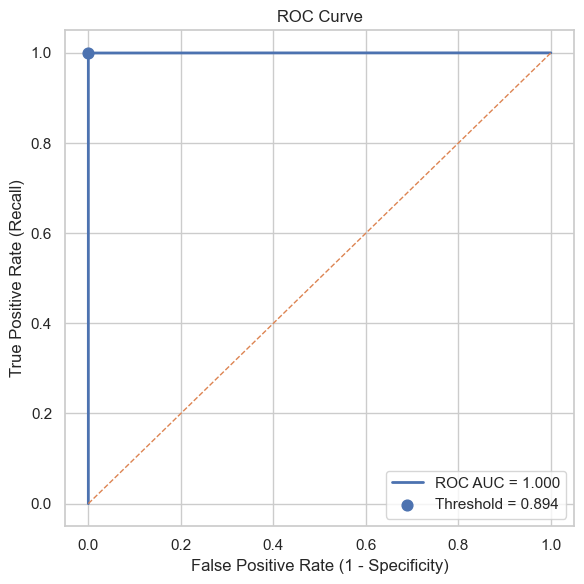

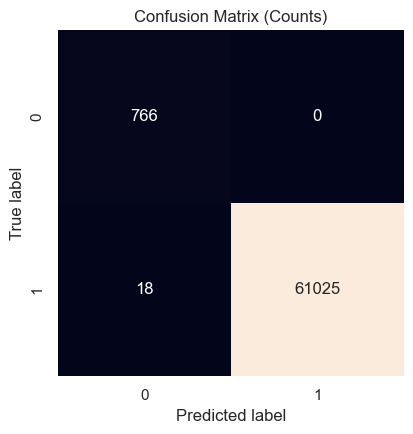

In [90]:
# === ROC Curve (with threshold point) ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix

roc_auc = roc_auc_score(y_test, proba_test)
fpr, tpr, thresholds = roc_curve(y_test, proba_test)

# 임계값 thr에 해당하는 점(성능) 계산
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
tpr_thr = tp / (tp + fn + 1e-12)  # Recall
fpr_thr = fp / (fp + tn + 1e-12)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f'ROC AUC = {roc_auc:.3f}', lw=2)
plt.plot([0, 1], [0, 1], '--', lw=1)
plt.scatter([fpr_thr], [tpr_thr], marker='o', s=60, label=f'Threshold = {thr:.3f}')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# === Confusion Matrix (counts) ===
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5.5,4.5))
sns.heatmap(cm, annot=True, fmt='d', cbar=False, square=True)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Counts)')
plt.tight_layout()
plt.show()


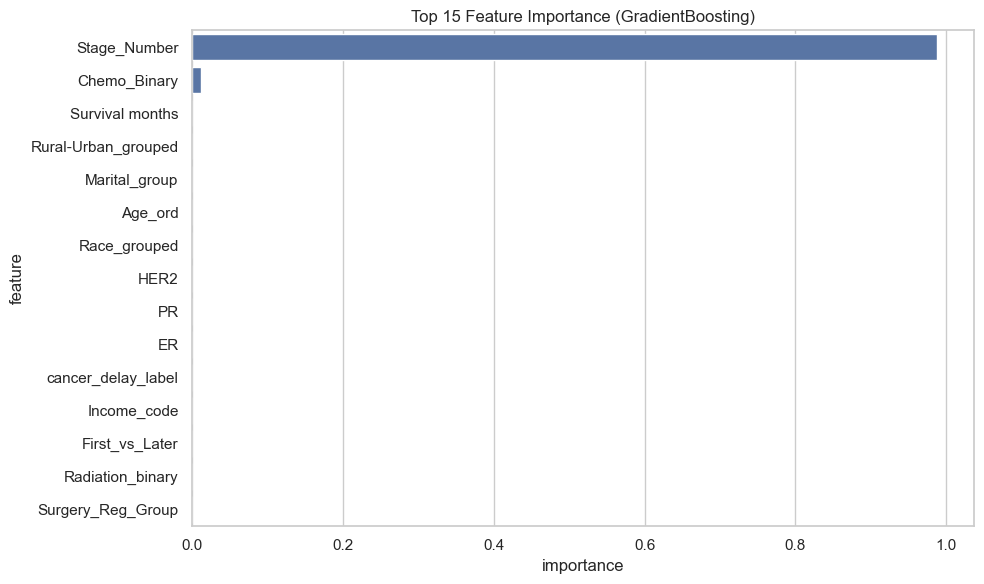

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

gb = final_pipe.named_steps["gb"]  # 파이프라인 안의 GB 모델
feat_importance = pd.DataFrame({
    "feature": X_train_use.columns,         # 누수 제거한 동일 컬럼
    "importance": gb.feature_importances_   # GB의 impurity-based 중요도
}).sort_values("importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="importance", y="feature", data=feat_importance.head(15))
plt.title("Top 15 Feature Importance (GradientBoosting)")
plt.tight_layout()
plt.show()

In [91]:

! pip install shap


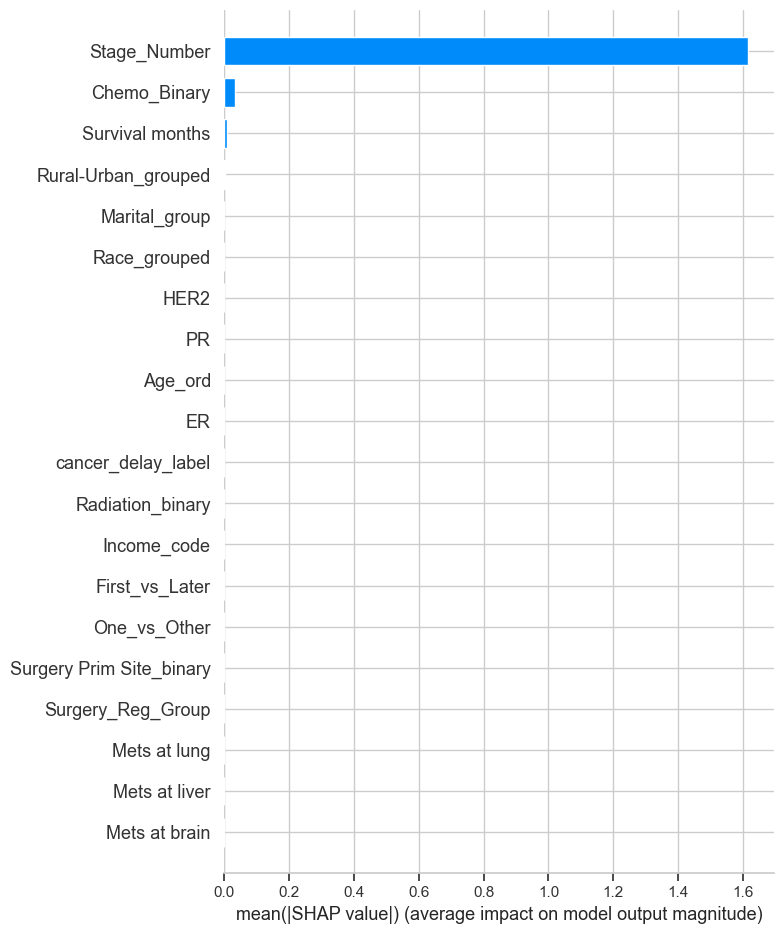

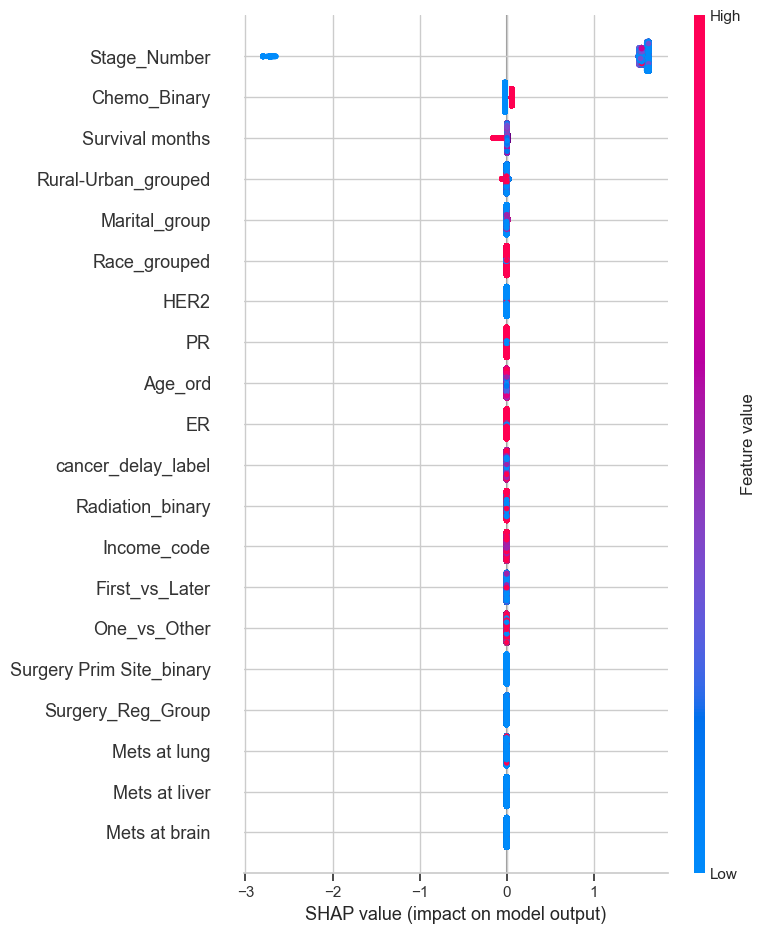

In [92]:
import shap

# 1) 파이프라인에서 학습된 GB 모델 꺼내기
gb = final_pipe.named_steps["gb"]

# 2) 설명할 데이터셋(누수 제거 컬럼 사용)
#    X_test_use가 없다면 fallback: X_test[use_cols]
X_te = X_test_use if 'X_test_use' in globals() else X_test[use_cols]

# 3) TreeExplainer 생성 (트리 계열에 최적화)
explainer = shap.TreeExplainer(gb)

# 4) SHAP 값 계산
shap_values = explainer.shap_values(X_te)

# 5) 이진분류에서 shap_values가 list로 나오는 버전 대비(클래스 1 기준 사용)
if isinstance(shap_values, list):
    sv = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    sv = shap_values  # (n_samples, n_features)

# 6) 요약 플롯: 바 차트(중요도) + 점 분포(영향 방향)
shap.summary_plot(sv, X_te, plot_type="bar")  # 전체 중요도
shap.summary_plot(sv, X_te)                   # 분포/방향성



In [106]:
import pandas as pd
import numpy as np

def _build_input_row(input_dict, features, default=0.0, alias=None):
    data = dict(input_dict) if input_dict is not None else {}
    if alias:
        for k, v in list(data.items()):
            if k in alias:
                data[alias[k]] = v
                del data[k]
    sr = pd.Series({c: data.get(c, default) for c in features}, index=features)
    sr = pd.to_numeric(sr, errors="coerce").fillna(default)
    return sr.to_frame().T  # (1, n_features)

def predict_malignancy_from_dict(input_dict, model, features=None, threshold=0.5, alias=None):
    # 학습 당시 컬럼 우선 사용
    features_req = getattr(model, "features_used_", None)
    if features_req is None:
        if features is None:
            raise ValueError("features_used_가 없고 features도 전달되지 않았습니다.")
        features_req = list(features)

    X1 = _build_input_row(input_dict, features_req, default=0.0, alias=alias)

    if not hasattr(model, "predict_proba"):
        raise ValueError("model은 predict_proba를 지원해야 합니다.")
    p1 = float(model.predict_proba(X1)[:, 1])   # malignant=1
    pred = int(p1 >= float(threshold))
    return {
        "proba_malignant": p1,
        "proba_benign": 1.0 - p1,
        "pred": pred,
        "threshold": float(threshold)
    }


In [161]:
# 누수 제거 컬럼으로 고정
X_train_use = X_train[use_cols].copy()
X_test_use  = X_test[use_cols].copy()

final_pipe.fit(X_train_use, y_train)

# 학습 당시 컬럼 목록을 모델에 저장(예측 때 재사용)
final_pipe.features_used_ = X_train_use.columns.tolist()


In [ ]:
# (재학습을 X_train_use로 끝냈다는 가정)
model = final_pipe
thr_use = thr  # 검증에서 고른 임계값

patient_input = {
    "Sex": 1, "ER": 1, "PR": 0, "HER2": 0,
    "Age_ord": 3, "Race_grouped": 1, "Marital_group": 1,
    "Rural-Urban_grouped": 3, "One_vs_Other": 1, "First_vs_Later": 1,
    "cancer_delay_label": 1, "Income_code": 3
}

res = predict_malignancy_from_dict(patient_input, model, features=use_cols, threshold=thr_use)
print(res)


{'proba_malignant': 0.6454449533317433, 'proba_benign': 0.35455504666825666, 'pred': 0, 'threshold': 0.8942762221616514}


C:\Users\user\AppData\Local\Temp\ipykernel_1536\3594962466.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p1 = float(model.predict_proba(X1)[:, 1])   # malignant=1


In [205]:
import pandas as pd
from IPython.display import display

def print_prediction_report(
    patient_key, proba_malignant, threshold=0.5, extra=None,
    risk_bins=(0.2, 0.5, 0.8),  # very_low / low / medium / high 경계
):
    p1 = float(proba_malignant)
    thr = float(threshold)
    pred = int(p1 >= thr)
    margin = (p1 - thr) * 100  # 퍼센트포인트
    p0 = 1.0 - p1

    # 리스크 밴드
    if p1 < risk_bins[0]:
        band = "very_low"
    elif p1 < risk_bins[1]:
        band = "low"
    elif p1 < risk_bins[2]:
        band = "medium"
    else:
        band = "high"

    # 예쁘게 출력
    title = f"환자: {patient_key}"
    line = "─" * max(30, len(title)+8)
    status = "악성(1)" if pred == 1 else "양성(0)"
    margin_note = "경계영역" if abs(margin) < 5 else ("상당히 여유" if abs(margin) >= 15 else "보통")

    print(f"┌{line}┐")
    print(f"│  {title}")
    print(f"│  예측 라벨 : {status}   (임계값 {thr:.3f})")
    print(f"│  악성 확률 : {p1*100:6.2f}%")
    print(f"│  양성 확률 : {p0*100:6.2f}%")
    print(f"│  임계값 대비 마진 : {margin:+6.2f} %p  → {margin_note}")
    print(f"│  Risk band : {band}")
    if extra:
        for k, v in extra.items():
            print(f"│  {k}: {v}")
    print(f"└{line}┘")

    # ✅ 쉼표 제거: DataFrame 자체를 반환
    return pd.DataFrame([{
        "patient": patient_key,
        "proba_malignant": round(p1, 6),
        "proba_benign": round(p0, 6),
        "pred": pred,
        "threshold": round(thr, 6),
        "margin_pct_point": round(margin, 2),
        "risk_band": band
    }])


# ---- 예측 호출부 ----
res = predict_malignancy_from_dict(patient_input, model=final_pipe, features=use_cols, threshold=thr)

# res 타입에 안전하게 대응 (DataFrame 또는 dict)
if isinstance(res, pd.DataFrame):
    # DataFrame 한 줄 반환 가정
    p1 = float(res.loc[0, "proba_malignant"])
    thr_use = float(res.loc[0, "threshold"]) if "threshold" in res.columns else float(thr)
    patient_key = res.loc[0, "patient"] if "patient" in res.columns else "홍길동"
elif isinstance(res, dict):
    p1 = float(res["proba_malignant"])
    thr_use = float(res.get("threshold", thr))
    patient_key = res.get("patient", "홍길동")
else:
    raise TypeError("predict_malignancy_from_dict가 dict 또는 1-row DataFrame을 반환하도록 맞춰주세요.")

df_row = print_prediction_report(
    patient_key=patient_key,
    proba_malignant=p1,
    threshold=thr_use,
    extra={"메모": "임상 검토 필요 시 연락"}
)

display(df_row)


┌──────────────────────────────┐
│  환자: 홍길동
│  예측 라벨 : 양성(0)   (임계값 0.894)
│  악성 확률 :  64.54%
│  양성 확률 :  35.46%
│  임계값 대비 마진 : -24.88 %p  → 상당히 여유
│  Risk band : medium
│  메모: 임상 검토 필요 시 연락
└──────────────────────────────┘


C:\Users\user\AppData\Local\Temp\ipykernel_1536\3594962466.py:27: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  p1 = float(model.predict_proba(X1)[:, 1])   # malignant=1


,patient,proba_malignant,proba_benign,pred,threshold,margin_pct_point,risk_band
0,홍길동,0.645445,0.354555,0,0.894276,-24.88,medium
